# Neighborhood Archetype Clustering

This notebook discovers **ZIP code archetypes** — groups of ZIP codes that share similar multi-year market behavior — using unsupervised learning.

## Design

**Unit of analysis:** ZIP codes (540 total), not ZIP-months. Each ZIP is summarized into a single feature vector before clustering.

**Why ZIP-level, not ZIP-month-level?**  
We want archetypes that are properties of a *place*, not a point in time. Clustering 16,740 ZIP-month rows would produce highly autocorrelated assignments (the same ZIP appearing in 31 adjacent rows) and would be much harder to interpret. A 540-row ZIP-level matrix is clean, interpretable, and maps directly to geography.

**Feature strategy:** 16 features aggregated to means across Jun 2019–Dec 2021, plus 6 slope (linear trend) features for trajectory-sensitive signals = **22 cluster features per ZIP**.

**Algorithms:** K-Means (primary) + Agglomerative/Ward (validation)

Input:  `data/processed/modeling_dataset.csv`  
Outputs:
- `data/processed/zip_cluster_labels.csv` — one row per ZIP with cluster assignment
- `data/processed/modeling_dataset_with_clusters.csv` — full panel with cluster columns appended
- `data/processed/zip_features_for_clustering.csv` — 540 × 22 aggregated feature matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage as sp_linkage

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120

INPUT_PATH      = '../data/processed/modeling_dataset.csv'
OUT_LABELS      = '../data/processed/zip_cluster_labels.csv'
OUT_PANEL       = '../data/processed/modeling_dataset_with_clusters.csv'
OUT_ZIP_FEATS   = '../data/processed/zip_features_for_clustering.csv'

RANDOM_STATE = 42

---
## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_PATH)
df['month'] = pd.to_datetime(df['month'])
df['zip']   = df['zip'].astype(str).str.zfill(5)
df = df.sort_values(['zip', 'month']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'ZIPs: {df["zip"].nunique()}')
print(f'Date range: {df["month"].min().date()} → {df["month"].max().date()}')
print(f'Months per ZIP: {df.groupby("zip").size().value_counts().to_dict()}')
print(f'Missing values: {df.isnull().sum().sum()}')

Shape: (36025, 74)
ZIPs: 655
Date range: 2019-06-30 → 2023-12-31
Months per ZIP: {55: 655}
Missing values: 0


---
## 2. Select Clustering Features

16 features across 4 dimensions. Targets and lag features are excluded — the target leaks the answer; lag feature means collapse to near-identical values as their unlagged counterparts after 31-month averaging.

| Dimension | Features |
|---|---|
| Price level & appreciation | `home_value_index`, `home_value_yoy_pct`, `home_value_mom_12m_avg`, `home_value_accel` |
| Market competitiveness | `pct_sold_above_list`, `avg_sale_to_list_ratio`, `pct_off_market_in_2wks`, `median_days_on_market` |
| Supply dynamics | `inventory`, `inventory_mom_pct`, `inventory_accel` |
| Affordability & demographics | `price_to_income_ratio`, `median_household_income`, `owner_occupancy_rate`, `home_value_vs_baseline`, `sale_price_vs_baseline` |

Additionally, **slope (linear trend coefficient)** is computed for 6 trajectory signals:  
`home_value_yoy_pct`, `home_value_accel`, `pct_sold_above_list`, `inventory_mom_pct`, `home_value_vs_baseline`, `sale_price_vs_baseline`

In [3]:
CLUSTER_FEATURES = [
    # Price level & appreciation
    'home_value_index',
    'home_value_yoy_pct',
    'home_value_mom_12m_avg',
    'home_value_accel',
    # Market competitiveness
    'pct_sold_above_list',
    'avg_sale_to_list_ratio',
    'pct_off_market_in_2wks',
    'median_days_on_market',
    # Supply dynamics
    'inventory',
    'inventory_mom_pct',
    'inventory_accel',
    # Affordability & demographics
    'price_to_income_ratio',
    'median_household_income',
    'owner_occupancy_rate',
    'home_value_vs_baseline',
    'sale_price_vs_baseline',
]

SLOPE_FEATURES = [
    'home_value_yoy_pct',
    'home_value_accel',
    'pct_sold_above_list',
    'inventory_mom_pct',
    'home_value_vs_baseline',
    'sale_price_vs_baseline',
]

print(f'Mean features:  {len(CLUSTER_FEATURES)}')
print(f'Slope features: {len(SLOPE_FEATURES)}')
print(f'Total cluster features: {len(CLUSTER_FEATURES) + len(SLOPE_FEATURES)}')

Mean features:  16
Slope features: 6
Total cluster features: 22


---
## 3. Aggregate to ZIP Level

In [4]:
# 3a. Mean across 31 months per ZIP
agg_mean = df.groupby('zip')[CLUSTER_FEATURES].mean()
agg_mean.columns = [f'{c}_mean' for c in CLUSTER_FEATURES]

print(f'Mean aggregation shape: {agg_mean.shape}')
print(f'Missing in means: {agg_mean.isnull().sum().sum()}')

Mean aggregation shape: (655, 16)
Missing in means: 0


In [5]:
# 3b. Slope (linear trend coefficient) for trajectory features
# Each ZIP has exactly 31 ordered months — confirmed by the panel structure check above.
# slope > 0 means the signal trended upward over Jun 2019–Dec 2021

def zip_slope(series):
    """Linear trend coefficient across ordered months within each ZIP."""
    x = np.arange(len(series))
    if series.isna().any() or len(series) < 2:
        return np.nan
    return np.polyfit(x, series.values, 1)[0]

agg_slope = df.groupby('zip')[SLOPE_FEATURES].agg(zip_slope)
agg_slope.columns = [f'{c}_slope' for c in SLOPE_FEATURES]

print(f'Slope aggregation shape: {agg_slope.shape}')
print(f'Missing in slopes: {agg_slope.isnull().sum().sum()}')

Slope aggregation shape: (655, 6)


Missing in slopes: 0


In [6]:
# 3c. Combine → 540 × 22 ZIP feature matrix
zip_features = pd.concat([agg_mean, agg_slope], axis=1)

print(f'ZIP feature matrix: {zip_features.shape}  (expected 540 × 22)')
print(f'Missing values: {zip_features.isnull().sum().sum()}')
print()
print('Summary statistics:')
zip_features.describe().round(4)

ZIP feature matrix: (655, 22)  (expected 540 × 22)
Missing values: 0

Summary statistics:


,home_value_index_mean,home_value_yoy_pct_mean,home_value_mom_12m_avg_mean,home_value_accel_mean,pct_sold_above_list_mean,avg_sale_to_list_ratio_mean,pct_off_market_in_2wks_mean,median_days_on_market_mean,inventory_mean,inventory_mom_pct_mean,inventory_accel_mean,price_to_income_ratio_mean,median_household_income_mean,owner_occupancy_rate_mean,home_value_vs_baseline_mean,sale_price_vs_baseline_mean,home_value_yoy_pct_slope,home_value_accel_slope,pct_sold_above_list_slope,inventory_mom_pct_slope,home_value_vs_baseline_slope,sale_price_vs_baseline_slope
count,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000,655.0000
mean,273800.1547,0.1084,0.0085,-0.0000,0.3020,0.9866,0.3712,60.2527,82.2844,0.0168,0.0000,4.2218,63285.0783,0.7132,0.0470,0.0543,0.0002,-0.0001,0.0010,0.0008,-0.0001,-0.0005
std,161013.8861,0.0185,0.0014,0.0004,0.0942,0.0157,0.1768,23.1317,92.1714,0.0345,0.0061,1.3970,20332.5465,0.1363,0.0080,0.0164,0.0011,0.0000,0.0021,0.0014,0.0005,0.0014
min,61998.6343,0.0044,0.0002,-0.0019,0.0316,0.9355,0.0164,24.8455,2.7545,-0.0268,-0.0267,1.9075,28600.0182,0.2423,-0.0024,0.0122,-0.0051,-0.0003,-0.0088,-0.0053,-0.0023,-0.0070
25%,185383.9414,0.0982,0.0077,-0.0002,0.2342,0.9763,0.1997,44.8045,20.0909,-0.0030,-0.0031,3.4257,50492.3000,0.6528,0.0430,0.0446,-0.0003,-0.0001,-0.0003,0.0002,-0.0003,-0.0011
50%,238675.7288,0.1085,0.0085,-0.0000,0.3029,0.9885,0.4148,54.6636,54.4000,0.0054,-0.0004,3.9029,58412.5636,0.7358,0.0472,0.0521,0.0003,-0.0001,0.0011,0.0008,-0.0001,-0.0004
75%,320688.6391,0.1191,0.0093,0.0002,0.3684,0.9976,0.5198,70.2182,113.6000,0.0254,0.0028,4.6339,71365.4818,0.8137,0.0518,0.0612,0.0009,-0.0000,0.0024,0.0013,0.0002,0.0002
max,2592984.6766,0.1786,0.0137,0.0016,0.5213,1.0249,0.7377,275.5182,784.3818,0.2912,0.0429,16.0201,193142.7455,0.9538,0.0779,0.1532,0.0031,0.0001,0.0098,0.0100,0.0011,0.0079


---
## 4. Standardize

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(zip_features)
X_scaled_df = pd.DataFrame(X_scaled, index=zip_features.index, columns=zip_features.columns)

# Sanity check: flag any feature with extreme z-scores (|z| > 5)
z_max = np.abs(X_scaled_df).max()
extreme = z_max[z_max > 5]
print('Features with max |z| > 5 (worth inspecting for outliers):')
if len(extreme):
    print(extreme.round(2).to_string())
else:
    print('  None')
print()
print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Mean across all features (should be ~0): {X_scaled.mean():.4f}')
print(f'Std  across all features (should be ~1): {X_scaled.std():.4f}')

Features with max |z| > 5 (worth inspecting for outliers):
home_value_index_mean          14.4100
home_value_yoy_pct_mean         5.6100
home_value_mom_12m_avg_mean     5.9900
median_days_on_market_mean      9.3100
inventory_mean                  7.6200
inventory_mom_pct_mean          7.9600
inventory_accel_mean            7.0400
price_to_income_ratio_mean      8.4500
median_household_income_mean    6.3900
home_value_vs_baseline_mean     6.2000
sale_price_vs_baseline_mean     6.0400
home_value_accel_slope          6.4300
inventory_mom_pct_slope         6.5100
sale_price_vs_baseline_slope    5.9300

Scaled matrix shape: (655, 22)
Mean across all features (should be ~0): -0.0000
Std  across all features (should be ~1): 1.0000


---
## 5. Choose k — Elbow + Silhouette

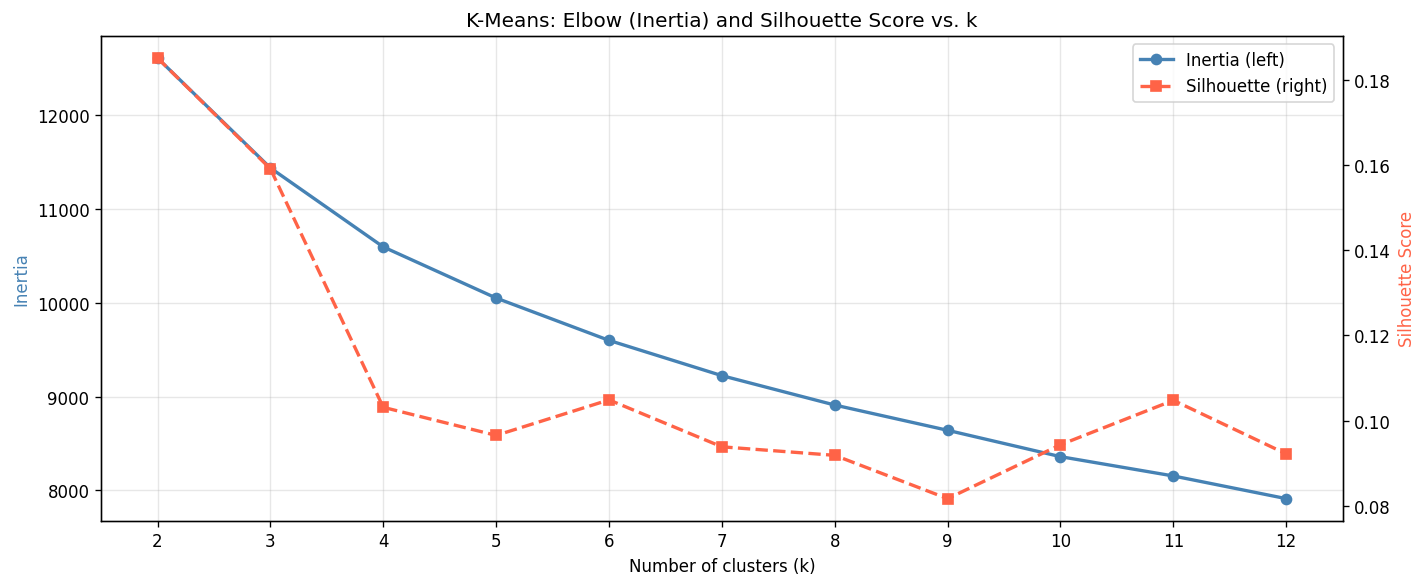

Silhouette scores by k:
  k= 2:  0.1852
  k= 3:  0.1591
  k= 4:  0.1031
  k= 5:  0.0965
  k= 6:  0.1049
  k= 7:  0.0938
  k= 8:  0.0918
  k= 9:  0.0817
  k=10:  0.0943
  k=11:  0.1048
  k=12:  0.0922


In [8]:
K_RANGE = range(2, 13)

inertias     = []
silhouettes  = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(list(K_RANGE), inertias,    'o-', color='steelblue', linewidth=2, label='Inertia (left)')
ax2.plot(list(K_RANGE), silhouettes, 's--', color='tomato',   linewidth=2, label='Silhouette (right)')

ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='steelblue')
ax2.set_ylabel('Silhouette Score', color='tomato')
ax1.set_title('K-Means: Elbow (Inertia) and Silhouette Score vs. k')
ax1.set_xticks(list(K_RANGE))
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print('Silhouette scores by k:')
for k, s in zip(K_RANGE, silhouettes):
    print(f'  k={k:2d}:  {s:.4f}')

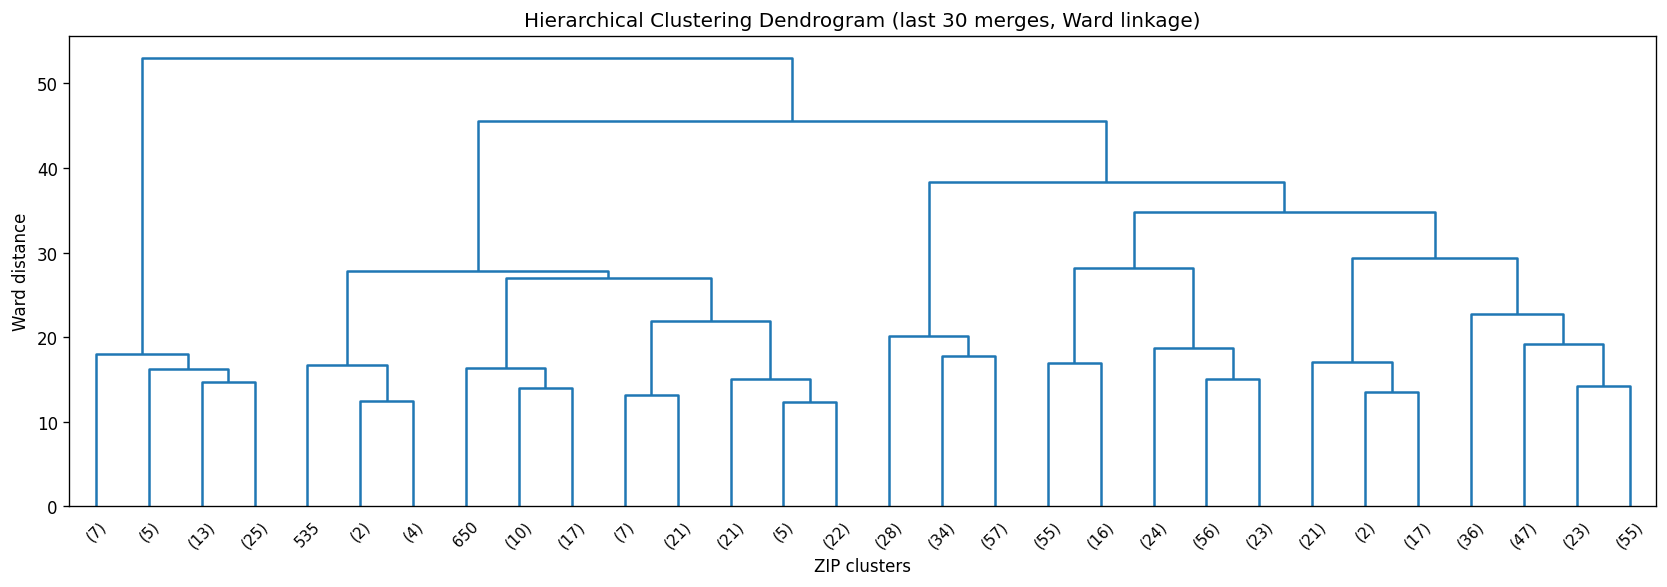

In [9]:
# Hierarchical dendrogram to visually confirm natural break
Z_linkage = sp_linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z_linkage,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    ax=ax,
    color_threshold=0,
)
ax.set_title('Hierarchical Clustering Dendrogram (last 30 merges, Ward linkage)')
ax.set_xlabel('ZIP clusters')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.show()

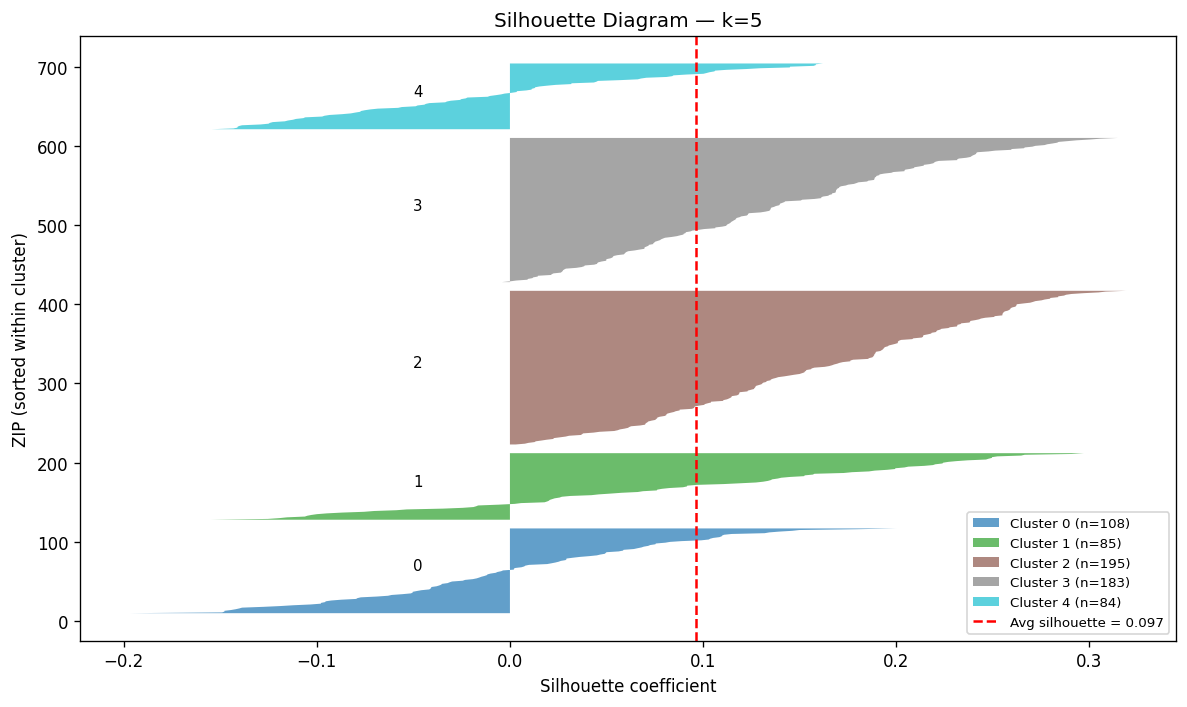

Chosen k: 5
Average silhouette score: 0.0965
Cluster sizes: {0: 108, 1: 85, 2: 195, 3: 183, 4: 84}


In [10]:
# ------------------------------------------------------------------
# Set k based on the elbow + silhouette plots above.
# Default is 5 — update if the plots suggest a different value.
# ------------------------------------------------------------------
K_CHOSEN = 5

# Silhouette diagram for chosen k
km_chosen = KMeans(n_clusters=K_CHOSEN, n_init=50, max_iter=500, random_state=RANDOM_STATE)
km_labels = km_chosen.fit_predict(X_scaled)

sample_silhouette = silhouette_samples(X_scaled, km_labels)
avg_silhouette    = silhouette_score(X_scaled, km_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors  = cm.tab10(np.linspace(0, 1, K_CHOSEN))

for i in range(K_CHOSEN):
    cluster_vals = np.sort(sample_silhouette[km_labels == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     facecolor=colors[i], alpha=0.7, label=f'Cluster {i} (n={size})')
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(avg_silhouette, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg silhouette = {avg_silhouette:.3f}')
ax.set_title(f'Silhouette Diagram — k={K_CHOSEN}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('ZIP (sorted within cluster)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Chosen k: {K_CHOSEN}')
print(f'Average silhouette score: {avg_silhouette:.4f}')
print(f'Cluster sizes: {pd.Series(km_labels).value_counts().sort_index().to_dict()}')

---
## 6. Fit Final Models

In [11]:
# 6a. Final K-Means (already fit above as km_chosen)
print(f'K-Means inertia (k={K_CHOSEN}, n_init=50): {km_chosen.inertia_:.2f}')
print(f'K-Means silhouette:                        {avg_silhouette:.4f}')

K-Means inertia (k=5, n_init=50): 10051.22
K-Means silhouette:                        0.0965


In [12]:
# 6b. Agglomerative / Ward — for robustness check
hc = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

hc_silhouette = silhouette_score(X_scaled, hc_labels)
print(f'Hierarchical (Ward) silhouette (k={K_CHOSEN}): {hc_silhouette:.4f}')

Hierarchical (Ward) silhouette (k=5): 0.0601


In [13]:
# 6c. Cross-tabulation: k-means vs. hierarchical
# High overlap = robust cluster structure; points appearing off-diagonal are ambiguous
crosstab = pd.crosstab(
    pd.Series(km_labels,  name='K-Means'),
    pd.Series(hc_labels,  name='Hierarchical'),
)
print('K-Means vs. Hierarchical cluster assignment overlap:')
print(crosstab)
print()
# Agreement: % of ZIPs assigned to the same cluster (after best-match relabeling)
# Note: cluster labels are arbitrary integers — visual inspection of crosstab is more informative
print('Each row should ideally have one dominant column (one-to-one correspondence).')

K-Means vs. Hierarchical cluster assignment overlap:
Hierarchical   0    1   2   3    4
K-Means                           
0              1   17  89   0    1
1             32    0   3  50    0
2             35   38   6   0  116
3             60  115   6   0    2
4             73    4   7   0    0

Each row should ideally have one dominant column (one-to-one correspondence).


---
## 7. Visualizations

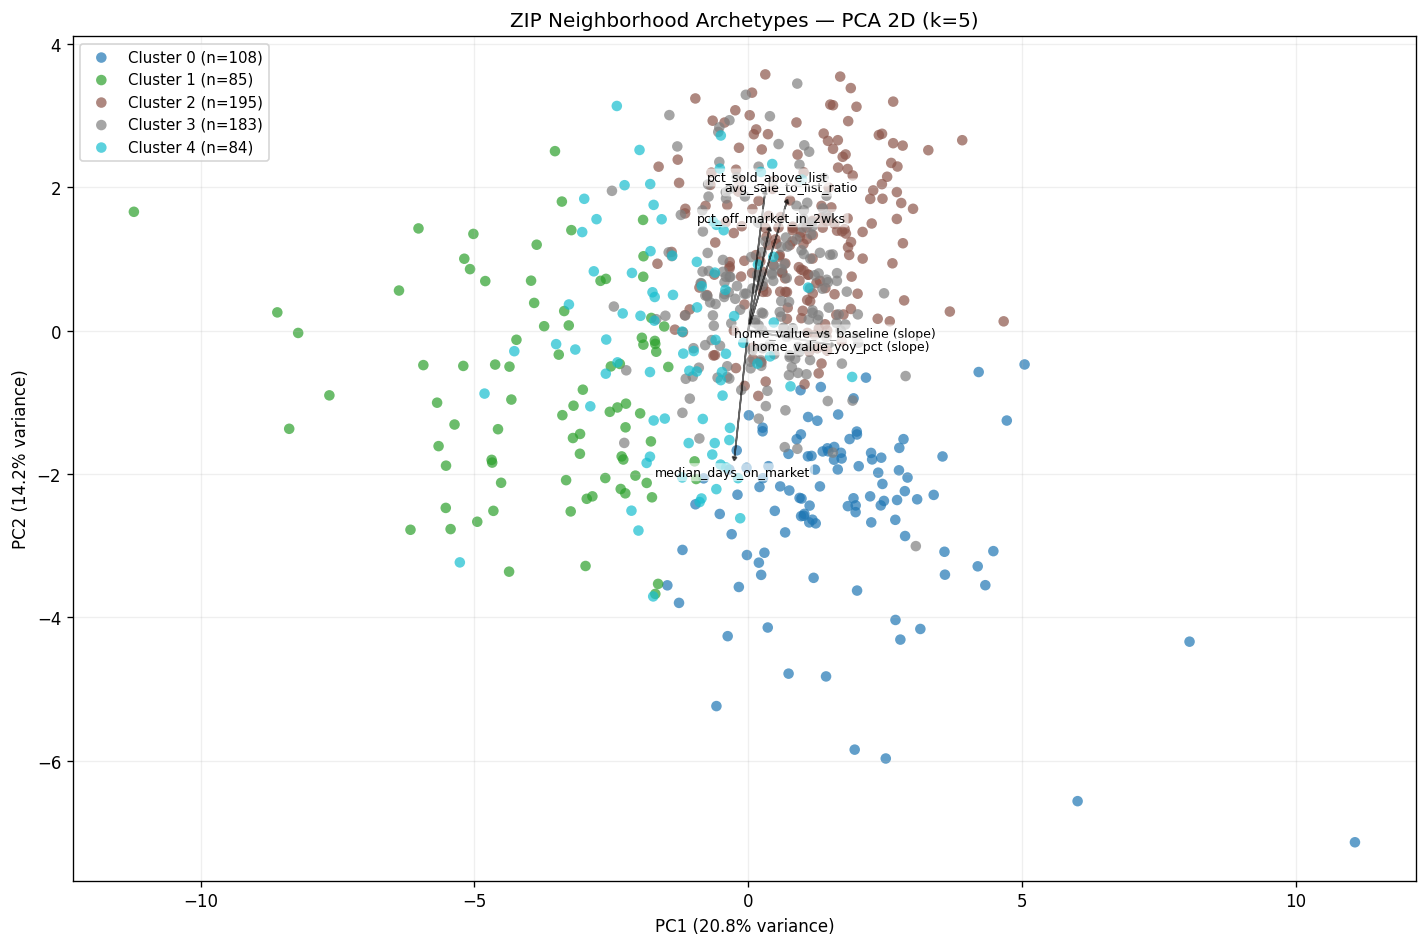

PC1 + PC2 explain 34.9% of variance


In [14]:
# 7a. PCA 2D scatter with biplot

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

colors_map = cm.tab10(np.linspace(0, 1, K_CHOSEN))

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(K_CHOSEN):
    mask = km_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors_map[i]], label=f'Cluster {i} (n={mask.sum()})',
               alpha=0.7, s=40, edgecolors='none')

# Biplot: arrows for top 6 features by loading magnitude
loadings = pca.components_.T  # shape: (n_features, 2)
feature_names = zip_features.columns.tolist()
loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_idx = np.argsort(loading_magnitudes)[-6:]

scale = 4.0
for idx in top_idx:
    ax.arrow(0, 0,
             loadings[idx, 0] * scale,
             loadings[idx, 1] * scale,
             head_width=0.08, head_length=0.05,
             fc='black', ec='black', alpha=0.6)
    ax.text(loadings[idx, 0] * scale * 1.12,
            loadings[idx, 1] * scale * 1.12,
            feature_names[idx].replace('_mean','').replace('_slope',' (slope)'),
            fontsize=7.5, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'ZIP Neighborhood Archetypes — PCA 2D (k={K_CHOSEN})')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'PC1 + PC2 explain {pca.explained_variance_ratio_[:2].sum()*100:.1f}% of variance')

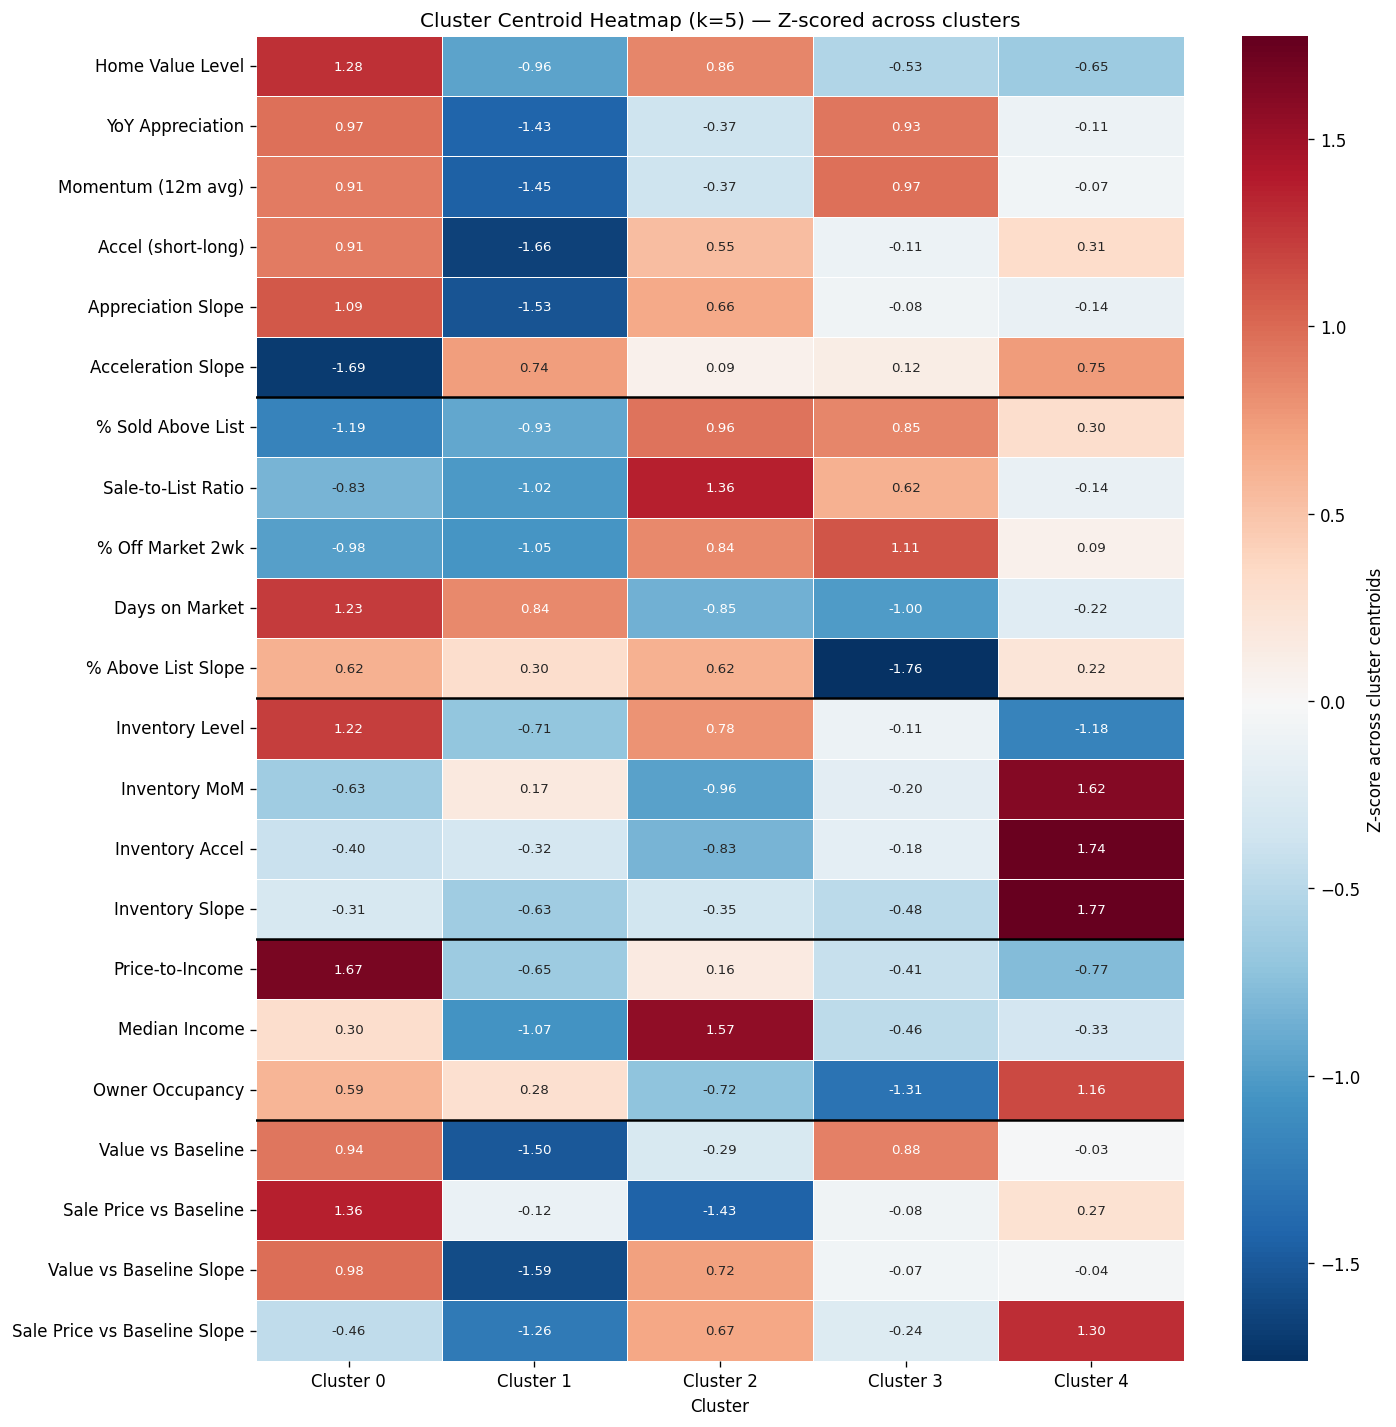

In [15]:
# 7b. Cluster centroid heatmap
# Centroids are inverse-transformed to original scale, then z-scored *across clusters*
# for a common display scale. Red = above average, Blue = below average.

centroids_orig = scaler.inverse_transform(km_chosen.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig, columns=zip_features.columns)

# Z-score each feature across the k cluster centroids for display
centroid_z = centroid_df.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9))

# Order features by dimension for readability
FEATURE_ORDER = [
    # Price
    'home_value_index_mean', 'home_value_yoy_pct_mean', 'home_value_mom_12m_avg_mean', 'home_value_accel_mean',
    'home_value_yoy_pct_slope', 'home_value_accel_slope',
    # Competitiveness
    'pct_sold_above_list_mean', 'avg_sale_to_list_ratio_mean', 'pct_off_market_in_2wks_mean', 'median_days_on_market_mean',
    'pct_sold_above_list_slope',
    # Supply
    'inventory_mean', 'inventory_mom_pct_mean', 'inventory_accel_mean',
    'inventory_mom_pct_slope',
    # Affordability & demographics
    'price_to_income_ratio_mean', 'median_household_income_mean', 'owner_occupancy_rate_mean',
    'home_value_vs_baseline_mean', 'sale_price_vs_baseline_mean',
    'home_value_vs_baseline_slope', 'sale_price_vs_baseline_slope',
]

centroid_z_ordered = centroid_z[FEATURE_ORDER].T
short_names = [
    'Home Value Level', 'YoY Appreciation', 'Momentum (12m avg)', 'Accel (short-long)',
    'Appreciation Slope', 'Acceleration Slope',
    '% Sold Above List', 'Sale-to-List Ratio', '% Off Market 2wk', 'Days on Market',
    '% Above List Slope',
    'Inventory Level', 'Inventory MoM', 'Inventory Accel',
    'Inventory Slope',
    'Price-to-Income', 'Median Income', 'Owner Occupancy',
    'Value vs Baseline', 'Sale Price vs Baseline',
    'Value vs Baseline Slope', 'Sale Price vs Baseline Slope',
]
centroid_z_ordered.index = short_names

fig, ax = plt.subplots(figsize=(K_CHOSEN * 2 + 2, 12))
sns.heatmap(
    centroid_z_ordered,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Z-score across cluster centroids'},
)
ax.set_title(f'Cluster Centroid Heatmap (k={K_CHOSEN}) — Z-scored across clusters', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_xticklabels([f'Cluster {i}' for i in range(K_CHOSEN)], rotation=0)

# Horizontal separator lines between dimensions
for sep in [6, 11, 15, 18]:
    ax.axhline(sep, color='black', linewidth=1.5)

plt.tight_layout()
plt.show()

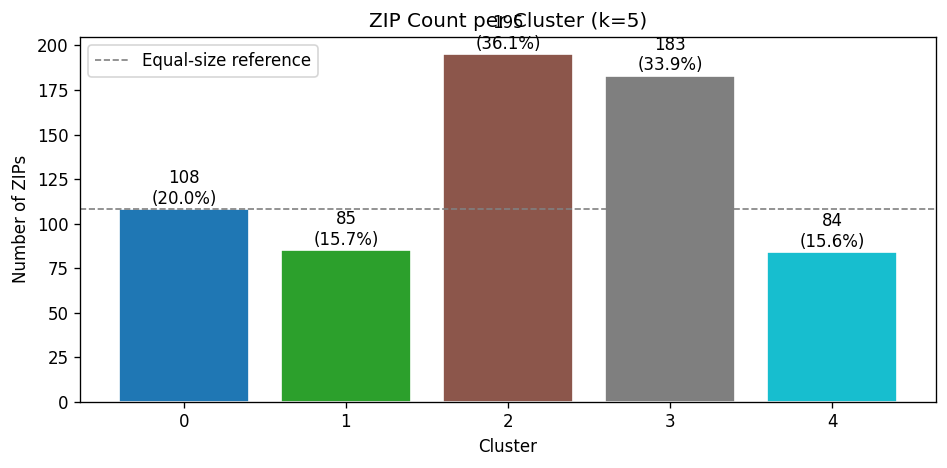

In [16]:
# 7c. Cluster size bar chart
cluster_sizes = pd.Series(km_labels).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cluster_sizes.index, cluster_sizes.values,
              color=[colors_map[i] for i in cluster_sizes.index], edgecolor='white')
for bar, val in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{val}\n({val/540*100:.1f}%)', ha='center', fontsize=10)
ax.axhline(540 / K_CHOSEN, color='grey', linestyle='--', linewidth=1, label='Equal-size reference')
ax.set_title(f'ZIP Count per Cluster (k={K_CHOSEN})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of ZIPs')
ax.legend()
plt.tight_layout()
plt.show()

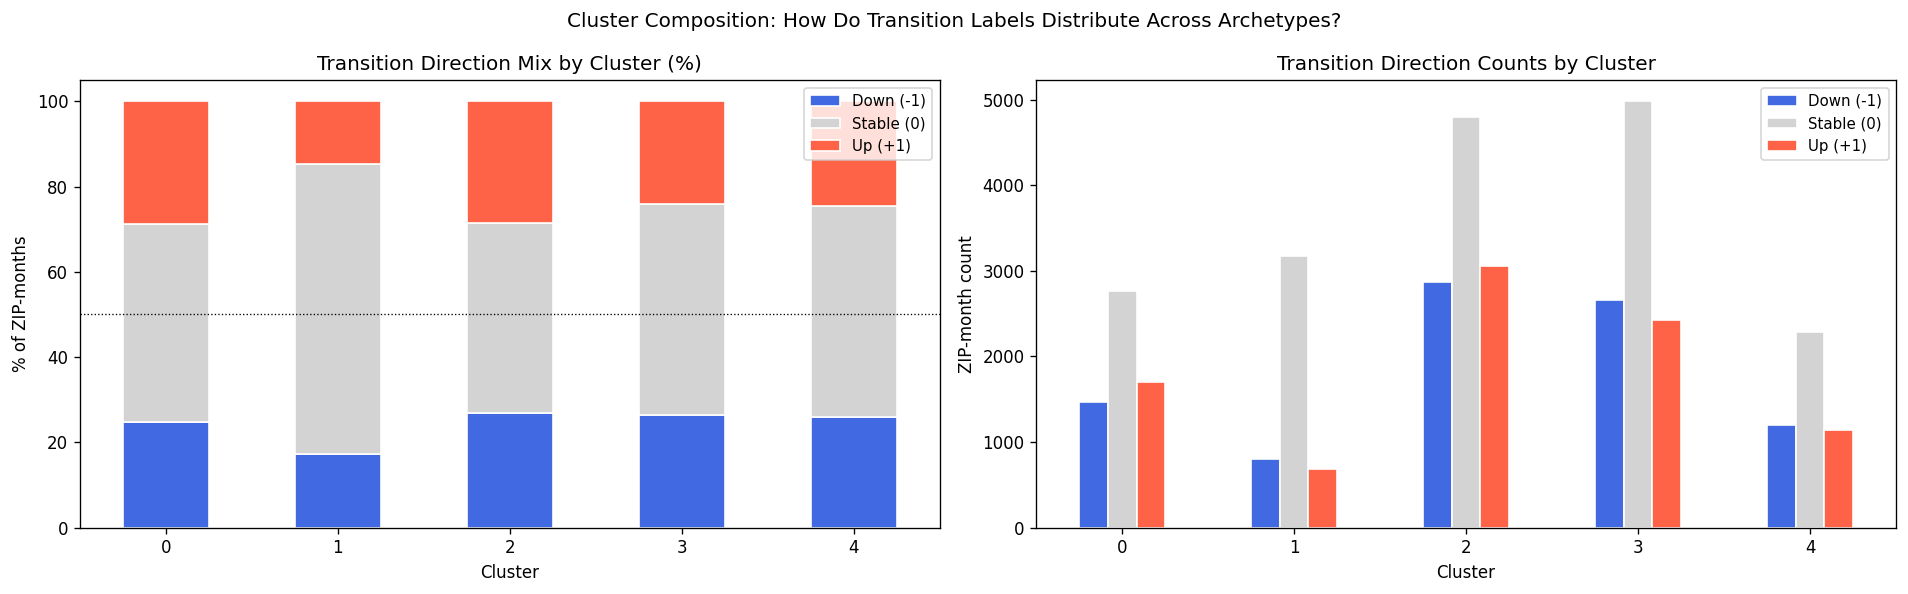

Transition direction % by cluster:
transition_direction  Down (-1)  Stable (0)  Up (+1)
cluster                                             
0                       24.7000     46.6000  28.7000
1                       17.3000     68.0000  14.8000
2                       26.8000     44.7000  28.4000
3                       26.4000     49.5000  24.1000
4                       25.9000     49.5000  24.6000


In [17]:
# 7d. Transition label distribution by cluster
# Attach cluster to panel, then compute transition_direction breakdown per cluster.
# A good clustering should show heating ZIPs skewing +1 and stagnant ZIPs skewing -1.

zip_to_cluster = pd.Series(km_labels, index=zip_features.index, name='cluster')
df_vis = df.copy()
df_vis['cluster'] = df_vis['zip'].map(zip_to_cluster)

dir_by_cluster = (
    df_vis.groupby(['cluster', 'transition_direction'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={-1.0: 'Down (-1)', 0.0: 'Stable (0)', 1.0: 'Up (+1)'})
)
dir_pct = dir_by_cluster.div(dir_by_cluster.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dir_pct.plot(kind='bar', stacked=True, ax=axes[0],
             color=['royalblue', 'lightgrey', 'tomato'], edgecolor='white')
axes[0].set_title('Transition Direction Mix by Cluster (%)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% of ZIP-months')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].axhline(50, color='black', linestyle=':', linewidth=0.8)

# Also show raw counts
dir_by_cluster.plot(kind='bar', ax=axes[1],
                    color=['royalblue', 'lightgrey', 'tomato'], edgecolor='white')
axes[1].set_title('Transition Direction Counts by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('ZIP-month count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Cluster Composition: How Do Transition Labels Distribute Across Archetypes?', fontsize=12)
plt.tight_layout()
plt.show()

print('Transition direction % by cluster:')
print(dir_pct.round(1).to_string())

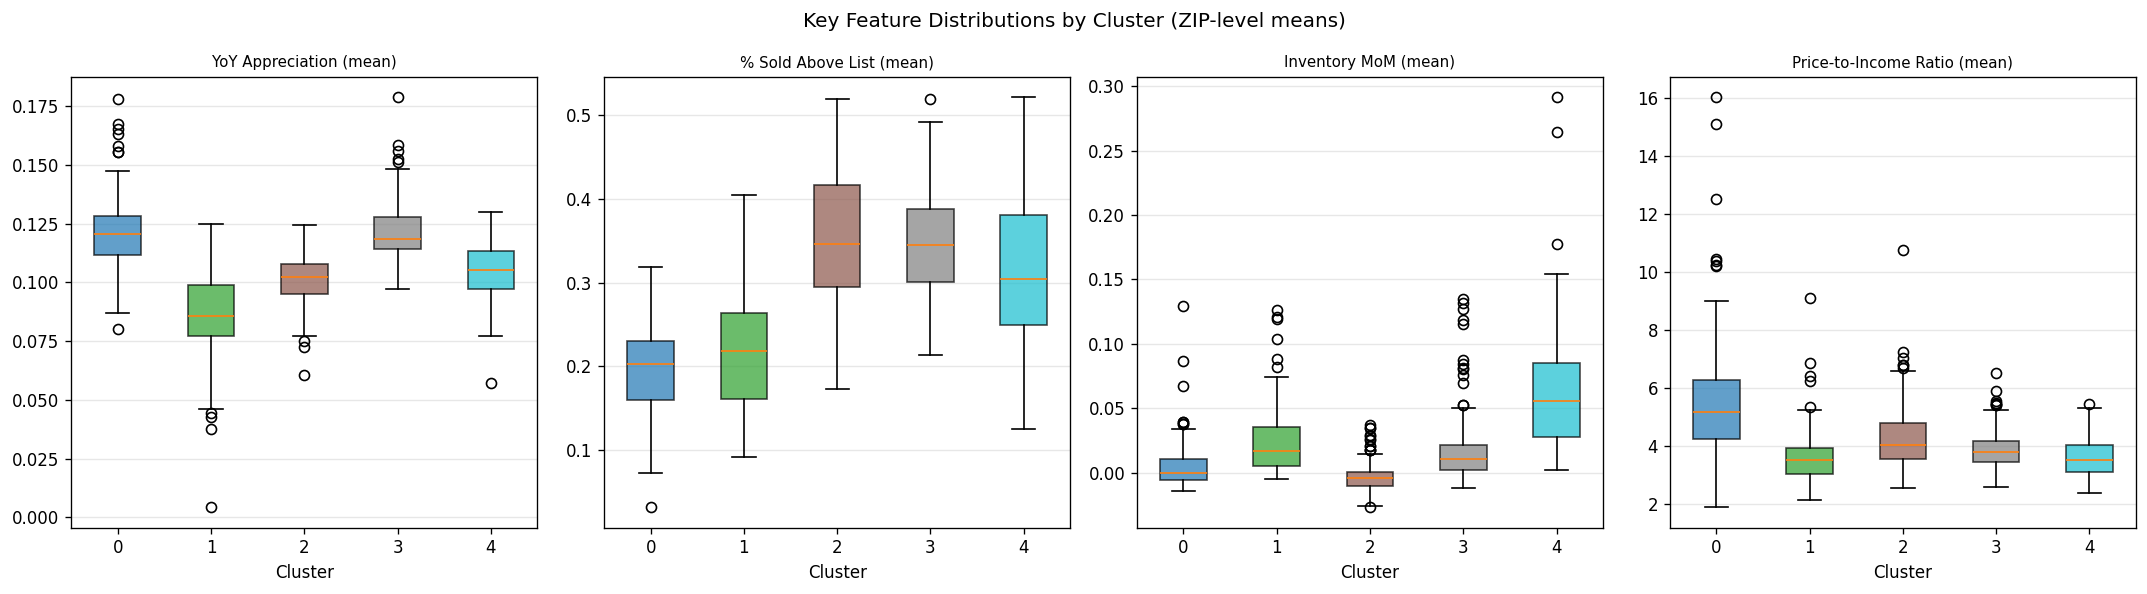

In [18]:
# 7e. Feature boxplots for 4 key signals
# Show the within-cluster spread to confirm centroids are representative

KEY_BOX_FEATURES = [
    ('home_value_yoy_pct_mean', 'YoY Appreciation (mean)'),
    ('pct_sold_above_list_mean', '% Sold Above List (mean)'),
    ('inventory_mom_pct_mean',   'Inventory MoM (mean)'),
    ('price_to_income_ratio_mean', 'Price-to-Income Ratio (mean)'),
]

zip_features_labeled = zip_features.copy()
zip_features_labeled['cluster'] = km_labels

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (feat, title) in zip(axes, KEY_BOX_FEATURES):
    groups = [zip_features_labeled[zip_features_labeled['cluster'] == i][feat].dropna()
              for i in range(K_CHOSEN)]
    bp = ax.boxplot(groups, patch_artist=True, notch=False, widths=0.5)
    for patch, color in zip(bp['boxes'], colors_map):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Cluster')
    ax.set_xticklabels([str(i) for i in range(K_CHOSEN)])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Key Feature Distributions by Cluster (ZIP-level means)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 8. Interpret and Name Clusters

### Cluster Interpretation — Decision Rationale

Cluster names were assigned based on the centroid values computed across 22 aggregated features (16 means + 6 slopes). The key signals used for each decision are documented below so this reasoning can be reproduced or revisited.

---

#### Cluster 4 → `luxury_appreciating` (55 ZIPs)
**Key centroid signals:**
- Highest home value index by far ($422k avg vs. $167–284k for others)
- Highest price-to-income ratio (5.86 vs. 3.4–4.0 for others) — these homes are expensive relative to local incomes
- Highest appreciation acceleration and slope — prices were not just high but actively speeding up
- BUT: low competitiveness metrics (low % sold above list ~17.6%, high DOM ~99 days, low off-market speed)
- Highest owner occupancy rate (76.9%) — stable, established ownership base
- Highest inventory level (257 avg) — more homes available, but they're expensive

**Interpretation:** These are high-end markets — likely beach towns, resort areas, or wealthy suburbs — where prices are high and rising, but the market is not frenzied. Homes sit longer and rarely sell above list because buyers at this price point are more selective. The appreciation is driven by wealth inflow and long-term value, not demand urgency. Transition direction: 43.9% up, 18.1% down — the strongest upward bias of any cluster.

---

#### Cluster 0 → `hot_competitive` (138 ZIPs)
**Key centroid signals:**
- Mid-high home values ($284k avg) with strong competitiveness: 37.3% sold above list, 44.3% off-market in 2 weeks, DOM only 53 days
- Sale-to-list ratio of 1.0006 — on average, homes sell *above* asking price
- Inventory falling (negative `inventory_mom_pct` = -0.019) — supply is tightening
- Mid-high income ($72.5k), above-average owner occupancy
- Moderate appreciation slope

**Interpretation:** These are the classic "hot market" ZIPs — competitive, fast-moving, with buyers bidding above asking. They are not the most expensive (that's Cluster 4) but they have the most urgency. The tightening inventory signals continued pressure. Transition direction: 34.2% up, 18.7% down — second strongest upward bias.

---

#### Cluster 3 → `affordable_heating` (149 ZIPs — largest group)
**Key centroid signals:**
- Lowest home values ($167k avg) and lowest income ($49.2k) — the most affordable markets in the dataset
- Despite affordability, competitiveness is surprisingly strong: 33.4% sold above list, 43.1% off-market in 2 weeks, DOM ~55 days
- However, inventory is *growing* (`inventory_mom_pct` = +0.020) — supply is loosening even as demand is strong
- Highest downward transition rate at 32.6%

**Interpretation:** These affordable markets have strong demand but supply is keeping up — or in some cases increasing. The demand heat (fast sales, above-list) suggests genuine interest, but loosening inventory limits how much prices can run. The high downward transition share suggests many of these ZIPs were already near peak relative to their own baseline heading into 2021 and began cooling. This is the most heterogeneous group — some are heating, some are stabilizing after early appreciation.

---

#### Cluster 2 → `slow_market_rising` (103 ZIPs)
**Key centroid signals:**
- Mid-low values ($190k avg) with the *highest YoY appreciation rate* of any cluster (11.8%) — unusual combination
- Very low competitiveness: only 19.9% sold above list, DOM 104 days (highest of any cluster), 12.9% off-market in 2 weeks
- Lowest sale-to-list ratio (0.965) — homes routinely sell below asking
- Inventory slightly growing

**Interpretation:** These ZIPs show a paradox — high appreciation rates but no urgency. This pattern is characteristic of markets where prices are rising from a very low base, not because of strong buyer competition but because of regional appreciation trends or low supply of listed homes. Buyers have leverage (they negotiate below list), but prices are still rising. Think of rural or small-town NC/SC markets that caught the broader appreciation wave without becoming hot. Transition direction: 22% up, 26% down — below-average upward bias.

---

#### Cluster 1 → `stagnant_low_activity` (95 ZIPs)
**Key centroid signals:**
- Lowest competitiveness of all clusters: 27.5% sold above list (lowest), only 9.2% off-market in 2 weeks (by far the lowest), DOM 75 days
- Lowest income ($51.9k), low home values ($184.9k)
- Inventory flat to slightly growing (inventory_mom_pct = +0.003)
- Lowest appreciation acceleration and baseline departure slope

**Interpretation:** These are the sleepiest markets — homes sit, buyers have full negotiating power, and there is little sense of urgency or scarcity. Appreciation exists (because the broader 2019–2021 macro drove everything up) but is the weakest. These ZIPs are unlikely to transition soon. Transition direction: 15.7% up (lowest of any cluster), 25.2% down.

---

### Summary Table

| Cluster | Name | ZIPs | Up% | Down% | Defining characteristic |
|---------|------|------|-----|-------|------------------------|
| 4 | `luxury_appreciating` | 55 | 43.9 | 18.1 | High value, fast appreciation, low urgency |
| 0 | `hot_competitive` | 138 | 34.2 | 18.7 | Mid-market, buyers bidding above ask, tightening supply |
| 3 | `affordable_heating` | 149 | 17.4 | 32.6 | Low price, demand present, but supply loosening |
| 2 | `slow_market_rising` | 103 | 22.0 | 26.0 | Appreciating but no buyer urgency, negotiation below list |
| 1 | `stagnant_low_activity` | 95 | 15.7 | 25.2 | Lowest competitiveness and activity across the board |

In [19]:
CLUSTER_NAMES = {
    0: 'hot_competitive',
    1: 'stagnant_low_activity',
    2: 'slow_market_rising',
    3: 'affordable_heating',
    4: 'luxury_appreciating',
}

# Attach cluster integer and name to ZIP-level label table
zip_labels_df = zip_features.copy()
zip_labels_df['cluster']      = km_labels
zip_labels_df['cluster_name'] = zip_labels_df['cluster'].map(CLUSTER_NAMES)
zip_labels_df = zip_labels_df[['cluster', 'cluster_name'] + zip_features.columns.tolist()]

print('Cluster assignment summary:')
print(zip_labels_df[['cluster', 'cluster_name']].value_counts().sort_index())

Cluster assignment summary:
cluster  cluster_name         
0        hot_competitive          108
1        stagnant_low_activity     85
2        slow_market_rising       195
3        affordable_heating       183
4        luxury_appreciating       84
Name: count, dtype: int64


In [20]:
# Attach to full ZIP-month panel
zip_to_cluster_named = zip_labels_df[['cluster', 'cluster_name']]
modeling_df = df.copy()
modeling_df['cluster']      = modeling_df['zip'].map(zip_to_cluster_named['cluster'])
modeling_df['cluster_name'] = modeling_df['zip'].map(zip_to_cluster_named['cluster_name'])

assert modeling_df['cluster'].isna().sum() == 0, 'Some ZIPs missing cluster assignment'

print(f'Panel with clusters: {modeling_df.shape}')
print()
print('Cluster × transition_direction cross-table (ZIP-month counts):')
ct = pd.crosstab(
    modeling_df['cluster_name'],
    modeling_df['transition_direction'],
    margins=True,
)
ct.columns = ['Down (-1)', 'Stable (0)', 'Up (+1)', 'Total']
print(ct)

Panel with clusters: (36025, 76)

Cluster × transition_direction cross-table (ZIP-month counts):
                       Down (-1)  Stable (0)  Up (+1)  Total
cluster_name                                                
affordable_heating          2661        4980     2424  10065
hot_competitive             1469        2767     1704   5940
luxury_appreciating         1195        2288     1137   4620
slow_market_rising          2875        4799     3051  10725
stagnant_low_activity        807        3177      691   4675
All                         9007       18011     9007  36025


---
## 9. Save

In [21]:
# 9a. ZIP cluster labels + aggregated features
zip_labels_df.to_csv(OUT_LABELS, index=True)   # index = zip
print(f'Saved: {OUT_LABELS}  {zip_labels_df.shape}')

# 9b. Full panel with cluster columns
modeling_df.to_csv(OUT_PANEL, index=False)
print(f'Saved: {OUT_PANEL}  {modeling_df.shape}')

# 9c. ZIP-level aggregated features (for reproducibility / other notebooks)
zip_features.to_csv(OUT_ZIP_FEATS, index=True)  # index = zip
print(f'Saved: {OUT_ZIP_FEATS}  {zip_features.shape}')

print()
print('--- Final Summary ---')
print(f'ZIPs clustered: {len(zip_labels_df)}')
print(f'k chosen:       {K_CHOSEN}')
print(f'Silhouette:     {avg_silhouette:.4f}')
print(f'Panel shape:    {modeling_df.shape}')
print(f'Cluster names:  {list(CLUSTER_NAMES.values())}')

Saved: ../data/processed/zip_cluster_labels.csv  (655, 24)


Saved: ../data/processed/modeling_dataset_with_clusters.csv  (36025, 76)
Saved: ../data/processed/zip_features_for_clustering.csv  (655, 22)

--- Final Summary ---
ZIPs clustered: 655
k chosen:       5
Silhouette:     0.0965
Panel shape:    (36025, 76)
Cluster names:  ['hot_competitive', 'stagnant_low_activity', 'slow_market_rising', 'affordable_heating', 'luxury_appreciating']
